In [1]:
import pandas as pd 
import numpy as np 
import plotly.express as px
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('datasets/preprocessed_dataset.csv')

In [3]:
sales_per_product = df.groupby('product_name')['price'].sum().reset_index().sort_values(by='price', ascending=False)

px.bar(
    sales_per_product.head(10),
    x = 'product_name',
    y = 'price',
    title = 'Top 10 Best Revenue Products',
    labels = {'product_name':'Product Name', 'price':'Total Sales'},
    color = 'price',
    color_continuous_scale = 'Viridis' 
).show()



In [4]:
df['actual_delivery_date'] = pd.to_datetime(df['actual_delivery_date'],errors='coerce')
df['estimated_delivery_date'] = pd.to_datetime(df['estimated_delivery_date'],errors='coerce')

In [5]:
df['year'] = df['actual_delivery_date'].dt.year

In [6]:
year_wise_sales = (
    df.set_index('actual_delivery_date')
    .resample('YE')['price']
    .sum()
    .reset_index()
)
year_wise_sales.rename(columns={'price': 'total_sales'}, inplace=True)

px.line(
    year_wise_sales, 
    x = 'actual_delivery_date',
    y = 'total_sales',
    title = 'Year-wise Sales Trend',
    labels = {'actual_delivery_date':'Year', 'total_sales':'Total Sales'},
    markers = True
).show()

In [7]:
top_cities = pd.pivot_table(
    df,
    index = 'year',
    columns = 'customer_city',
    values = 'price',
    aggfunc = 'count',
    fill_value = 0
).idxmax(axis = 1).reset_index().rename(columns = { 0:'top_city'})

fig = px.bar(
    top_cities,
    x='year',
    y=[1]*len(top_cities),
    text='top_city',
    title='Top Ordering City by Year'
)

fig.update_traces(textposition='outside')
fig.update_yaxes(visible=False)

fig.show()

In [8]:
best_selling_product_each_year = pd.pivot_table(
    df,
    index = 'product_name',
    columns = 'year',
    values = 'price',
    aggfunc = 'sum',
    fill_value = 0
).idxmax(axis = 0).reset_index().rename(columns = {'index':'year', 0:'best_selling_product'}).head(5)

px.scatter(
    best_selling_product_each_year,
    x = 'year',
    y = 'best_selling_product',
    title = 'Best Selling Product Each Year',
    color='best_selling_product'
   ).show()

In [9]:
most_reviewed_product = df.groupby('product_name')['review_score'].mean().reset_index().sort_values(by='review_score', ascending=False).head(10)

least_reviewed_product = df.groupby('product_name')['review_score'].mean().reset_index().sort_values(by='review_score', ascending=False).tail(10)

In [10]:
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=('Top 10 Most Reviewed Products', 'Top 10 Least Reviewed Products')
)

fig_1 = px.bar(
    most_reviewed_product,
    x='review_score',
    y='product_name',
    color='review_score',
    orientation='h',
    labels={'product_name': 'Product Name', 'review_score': 'Avg Review'}
)

fig_2 = px.bar(
    least_reviewed_product,
    x='review_score',
    y='product_name',
    color='review_score',
    orientation='h',
    labels={'product_name': 'Product Name', 'review_score': 'Avg Review'}
)

for trace in fig_1.data:
    fig.add_trace(trace, row=1, col=1)

for trace in fig_2.data:
    fig.add_trace(trace, row=2, col=1)

fig.update_layout(
    title_text='Product Review Scores Comparison',
    showlegend=False
)

fig.show()

<Axes: ylabel='product_name'>

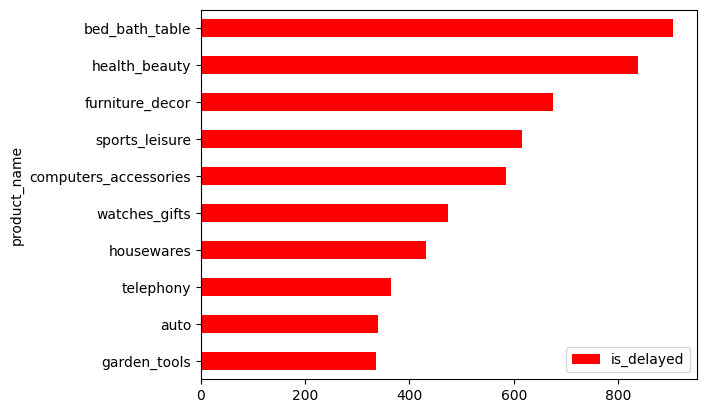

In [11]:
most_delayed_products = pd.pivot_table(
    df, 
    index = 'product_name',
    values = 'is_delayed',
    aggfunc='sum'
).reset_index().sort_values(by='is_delayed', ascending=False).head(10)

most_delayed_products.sort_values(by='is_delayed', ascending=True).head(10).plot(kind='barh', x='product_name', y='is_delayed', color='red' )


In [12]:
top_selling_products_recent_year = pd.DataFrame(df.groupby(['year','product_name'])['price'].count().loc[df['year'].max()].sort_values(ascending=False)).reset_index().head(10)

px.bar(
    top_selling_products_recent_year,
    x='product_name',
    y='price',
    title=f'Top 10 Selling Products in {int(df["year"].max())}',
    labels={'product_name': 'Product Name', 'price': 'Total Sales'},
    color='price',
    color_continuous_scale='Viridis'
)


In [13]:
most_delayed_cities = df.groupby('customer_city')['is_delayed'].sum().reset_index().sort_values(by='is_delayed',ascending=False).head(10)
px.treemap(
    most_delayed_cities, 
    path =['customer_city'],
    values = 'is_delayed',
    title = 'Most Delayed Cities'
)